#**1. Mount Data.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**2. Import Libraries.**


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay

#**3. Load the Dataset.**

In [3]:
import pandas as pd

url = 'https://assets.codingdojo.com/boomyeah2015/codingdojo/curriculum/content/chapter/1613253521__modifiedIris2Classes.csv'
df = pd.read_csv(url)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,7.0,3.2,4.7,1.4,0
1,6.4,3.2,4.5,1.5,0
2,6.9,3.1,4.9,1.5,0
3,5.5,2.3,4.0,1.3,0
4,6.5,2.8,4.6,1.5,0


#**Build a Logistic Regression Classifier**

In [4]:
# Split into X and y
X = df.drop(columns = 'target')
y = df['target']
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=3)
# Make an instance of the model
logreg = LogisticRegression(C = .001)
# Scaling logistic regression
scaler = StandardScaler()
# Create pipeline
logreg_pipe = make_pipeline(scaler, logreg)
# Training the model on the data, storing the information learned from the data
# Model is learning the relationship between X and y
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=0.001))])

#**Calculate AUC and Visualize ROC**

In [5]:
# Calculate AUC for both training and testing sets
print(f'Training AUC: {roc_auc_score(y_train, logreg_pipe.predict_proba(X_train)[:,1])}')
print(f'Testing AUC: {roc_auc_score(y_test, logreg_pipe.predict_proba(X_test)[:,1])}')

Training AUC: 0.9565527065527065
Testing AUC: 0.987012987012987


**يعني Testing أعلى من Training —
 النموذج بيعمم كويس ومش overfitting ✅**

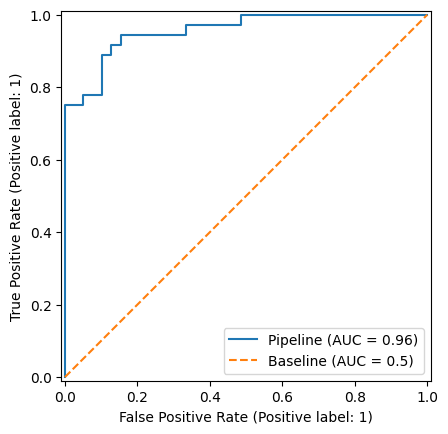

In [6]:
# Visualize the ROC curve
RocCurveDisplay.from_estimator(logreg_pipe, X_train, y_train)
plt.plot([0, 1], [0, 1], ls = '--', label = 'Baseline (AUC = 0.5)')
plt.legend();

منحنى أزرق = أداء النموذج — بيروح لأعلى اليسار
خط متقطع = الـ baseline (عشوائي AUC=0.5)

كلما كان المنحنى فوق وبعيد عن الخط المتقطع = أحسن ✅

#**ROC Curves for Multiclass Classification**

In [7]:
# Load multiclass iris data
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
y.unique()

array([0, 1, 2])

In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# Fit a logistic regression model
clf = LogisticRegression(multi_class='ovr', C=.01)
clf.fit(X_train, y_train)
# Retrieve the predicted probabilities for the test data
y_pred = clf.predict_proba(X_test)
y_pred[:5].round(2)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


array([[0.16, 0.33, 0.51],
       [0.28, 0.34, 0.37],
       [0.62, 0.24, 0.14],
       [0.08, 0.32, 0.6 ],
       [0.61, 0.26, 0.14]])

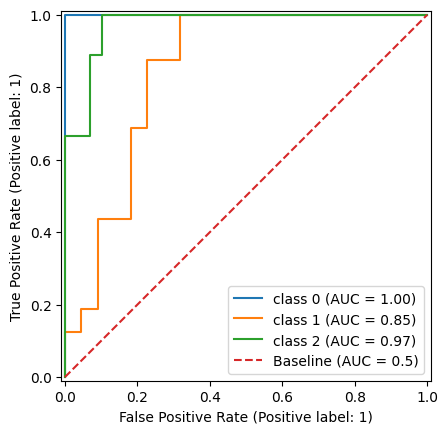

In [10]:
from sklearn.preprocessing import label_binarize

# حولي y_test لـ binary matrix
y_test_bin = label_binarize(y_test, classes=clf.classes_)

fig, ax = plt.subplots(1)

for i, label in enumerate(clf.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_pred[:, i],
        pos_label=1,
        ax=ax,
        name=f'class {label}'
    )

ax.plot([0, 1], [0, 1], ls='--', label='Baseline (AUC = 0.5)')
plt.legend()
plt.show()

**كلما المنحنى أقرب للزاوية العليا اليسار = النموذج أحسن بتمييز هاي الفئة عن الباقين**

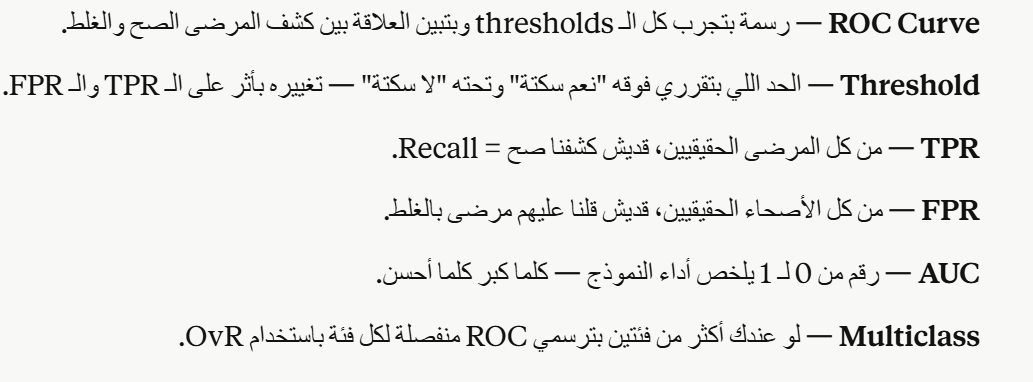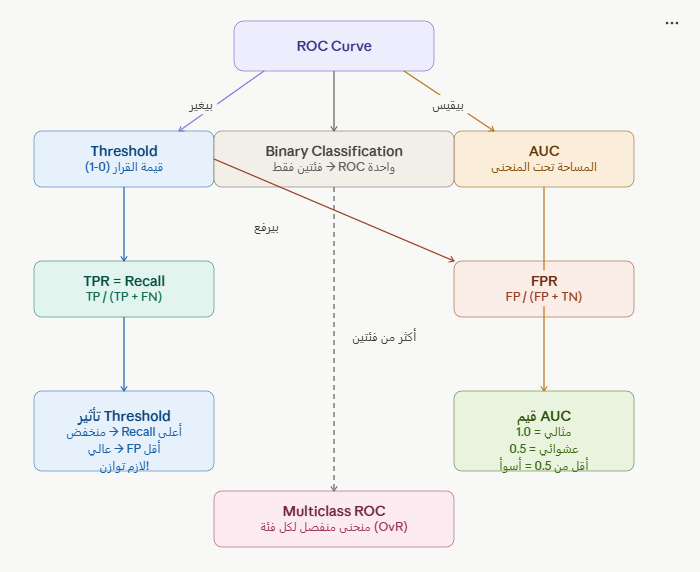